# Project: Gradient Descent Visualizer

## 0. Overview

**Problem statement:** Gradient descent is the engine of all learned models. But watching a loss curve decline tells you little about *why* it behaves as it does — why certain learning rates diverge, why momentum helps in ravines, why Adam adapts. This project builds a self-contained visualizer that makes the geometry of gradient descent legible.

**Concepts applied:**
- Gradient computation and backpropagation (ch209, ch216)
- Gradient descent variants (ch212, ch227)
- Optimization landscapes: saddle points, ravines (ch213, ch214)
- Taylor series: quadratic approximation of loss (ch219)

**Expected output:** Animated trajectory plots on several 2D loss surfaces, with side-by-side optimizer comparison.

**Difficulty:** Intermediate. Estimated time: 60–90 min.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

np.random.seed(42)
print("Setup complete.")


Setup complete.


## 1. Setup — Loss Surface Library

In [2]:
# Define a set of canonical 2D loss surfaces for visualisation

def quadratic(w):
    w1, w2 = w
    return (w1 - 1)**2 + 5*(w2 - 1)**2

def grad_quadratic(w):
    w1, w2 = w
    return np.array([2*(w1 - 1), 10*(w2 - 1)])

def rosenbrock(w):
    x, y = w
    return (1 - x)**2 + 100*(y - x**2)**2

def grad_rosenbrock(w):
    x, y = w
    dx = -2*(1 - x) - 400*x*(y - x**2)
    dy = 200*(y - x**2)
    return np.array([dx, dy])

def saddle(w):
    x, y = w
    return x**2 - y**2

def grad_saddle(w):
    x, y = w
    return np.array([2*x, -2*y])

surfaces = {
    'Quadratic (ideal)': (quadratic, grad_quadratic, [2.5, 2.5], (-0.5, 3.5), (-0.5, 3.5)),
    'Rosenbrock (valley)': (rosenbrock, grad_rosenbrock, [-1.0, 2.0], (-2, 2), (-0.5, 3.5)),
    'Saddle Point': (saddle, grad_saddle, [1.5, 0.1], (-2.5, 2.5), (-2.5, 2.5)),
}
print("Loss surfaces defined:", list(surfaces.keys()))


Loss surfaces defined: ['Quadratic (ideal)', 'Rosenbrock (valley)', 'Saddle Point']


## 2. Stage 1 — Optimizer Implementations

In [3]:
class OptimizerBase:
    def __init__(self, lr):
        self.lr = lr
        self.state = {}

    def step(self, w, grad):
        raise NotImplementedError

class SGD(OptimizerBase):
    def step(self, w, grad):
        return w - self.lr * grad

class MomentumSGD(OptimizerBase):
    def __init__(self, lr, mu=0.9):
        super().__init__(lr); self.mu = mu
    def step(self, w, grad):
        v = self.state.get('v', np.zeros_like(w))
        v = self.mu * v + grad
        self.state['v'] = v
        return w - self.lr * v

class Adam(OptimizerBase):
    def __init__(self, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8):
        super().__init__(lr)
        self.beta1, self.beta2, self.eps = beta1, beta2, eps
    def step(self, w, grad):
        t  = self.state.get('t', 0) + 1
        m  = self.beta1 * self.state.get('m', np.zeros_like(w)) + (1 - self.beta1) * grad
        v  = self.beta2 * self.state.get('v', np.zeros_like(w)) + (1 - self.beta2) * grad**2
        self.state.update({'t': t, 'm': m, 'v': v})
        m_hat = m / (1 - self.beta1**t)
        v_hat = v / (1 - self.beta2**t)
        return w - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

def run_optimizer(opt, grad_fn, w0, n_steps=200):
    w = w0.copy().astype(float)
    path = [w.copy()]
    for _ in range(n_steps):
        g = grad_fn(w)
        w = opt.step(w, g)
        path.append(w.copy())
    return np.array(path)

print("Optimizers: SGD, MomentumSGD, Adam")


Optimizers: SGD, MomentumSGD, Adam


## 3. Stage 2 — Trajectory Visualisation

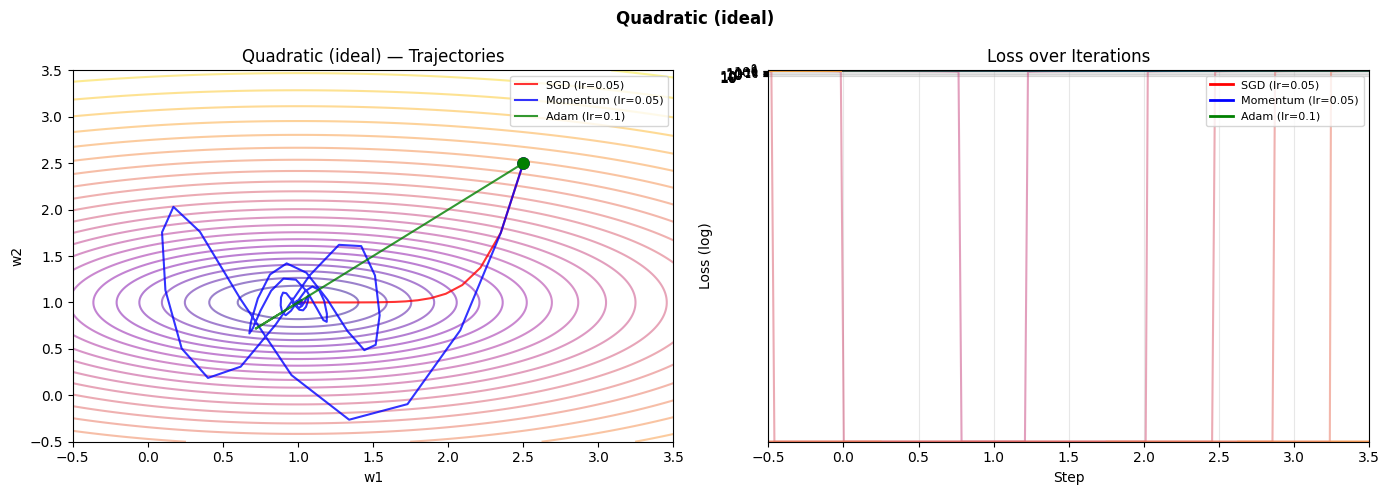

C:\Users\user\AppData\Local\Temp\ipykernel_24116\2162303551.py:17: RuntimeWarning: overflow encountered in scalar power
  dx = -2*(1 - x) - 400*x*(y - x**2)
C:\Users\user\AppData\Local\Temp\ipykernel_24116\2162303551.py:18: RuntimeWarning: overflow encountered in scalar power
  dy = 200*(y - x**2)
C:\Users\user\AppData\Local\Temp\ipykernel_24116\2162303551.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  dx = -2*(1 - x) - 400*x*(y - x**2)
C:\Users\user\AppData\Local\Temp\ipykernel_24116\2162303551.py:18: RuntimeWarning: invalid value encountered in scalar subtract
  dy = 200*(y - x**2)
C:\Users\user\AppData\Local\Temp\ipykernel_24116\2162303551.py:13: RuntimeWarning: overflow encountered in scalar power
  return (1 - x)**2 + 100*(y - x**2)**2
C:\Users\user\AppData\Local\Temp\ipykernel_24116\2162303551.py:13: RuntimeWarning: invalid value encountered in scalar subtract
  return (1 - x)**2 + 100*(y - x**2)**2


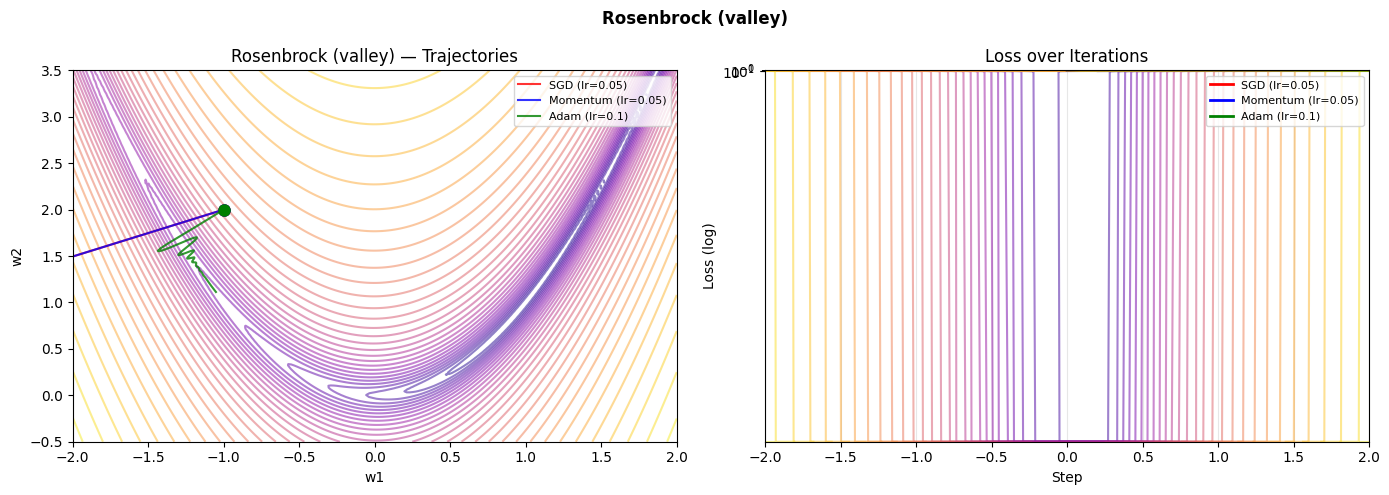

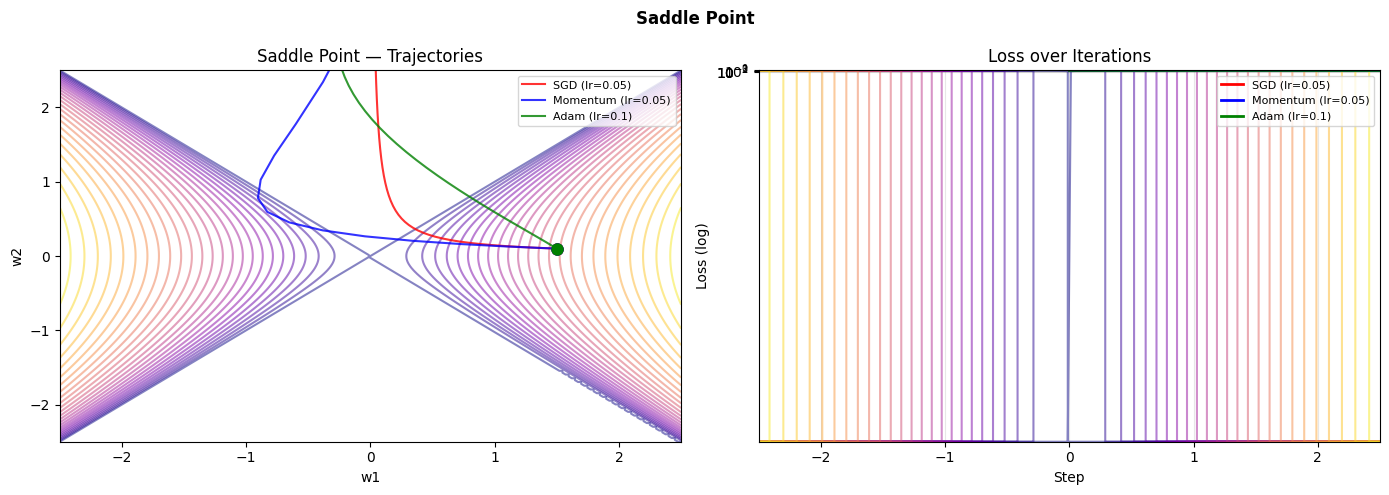

In [4]:
def plot_trajectories(surface_name, n_steps=150, n_contours=30):
    loss_fn, grad_fn, w0, xlim, ylim = surfaces[surface_name]

    # Build contour grid
    xs = np.linspace(*xlim, 200)
    ys = np.linspace(*ylim, 200)
    X, Y = np.meshgrid(xs, ys)
    Z = np.vectorize(lambda x, y: loss_fn([x, y]))(X, Y)
    Z_log = np.log1p(np.clip(Z, 0, None))  # log scale for better visual

    optimizers = {
        'SGD (lr=0.05)':          SGD(lr=0.05),
        'Momentum (lr=0.05)':     MomentumSGD(lr=0.05),
        'Adam (lr=0.1)':          Adam(lr=0.1),
    }
    colors = ['red', 'blue', 'green']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax in axes:
        ax.contour(X, Y, Z_log, levels=n_contours, cmap='plasma', alpha=0.5)
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_xlabel('w1'); ax.set_ylabel('w2')

    axes[0].set_title(f'{surface_name} — Trajectories')
    axes[1].set_title('Loss over Iterations')

    for (name, opt), color in zip(optimizers.items(), colors):
        path = run_optimizer(opt, grad_fn, np.array(w0), n_steps)
        losses = [loss_fn(w) for w in path]
        axes[0].plot(path[:, 0], path[:, 1], '-', color=color, lw=1.5, alpha=0.8, label=name)
        axes[0].plot(path[0, 0], path[0, 1], 'o', color=color, ms=8)
        axes[1].semilogy(losses, color=color, lw=2, label=name)

    axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
    axes[1].set_xlabel('Step'); axes[1].set_ylabel('Loss (log)')
    axes[1].grid(True, which='both', alpha=0.3)
    plt.suptitle(surface_name, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"ch228_{surface_name.replace(' ', '_').replace('(', '').replace(')', '')}.png", dpi=100)
    plt.show()

for name in surfaces:
    plot_trajectories(name)


## 4. Stage 3 — Learning Rate Sensitivity Study

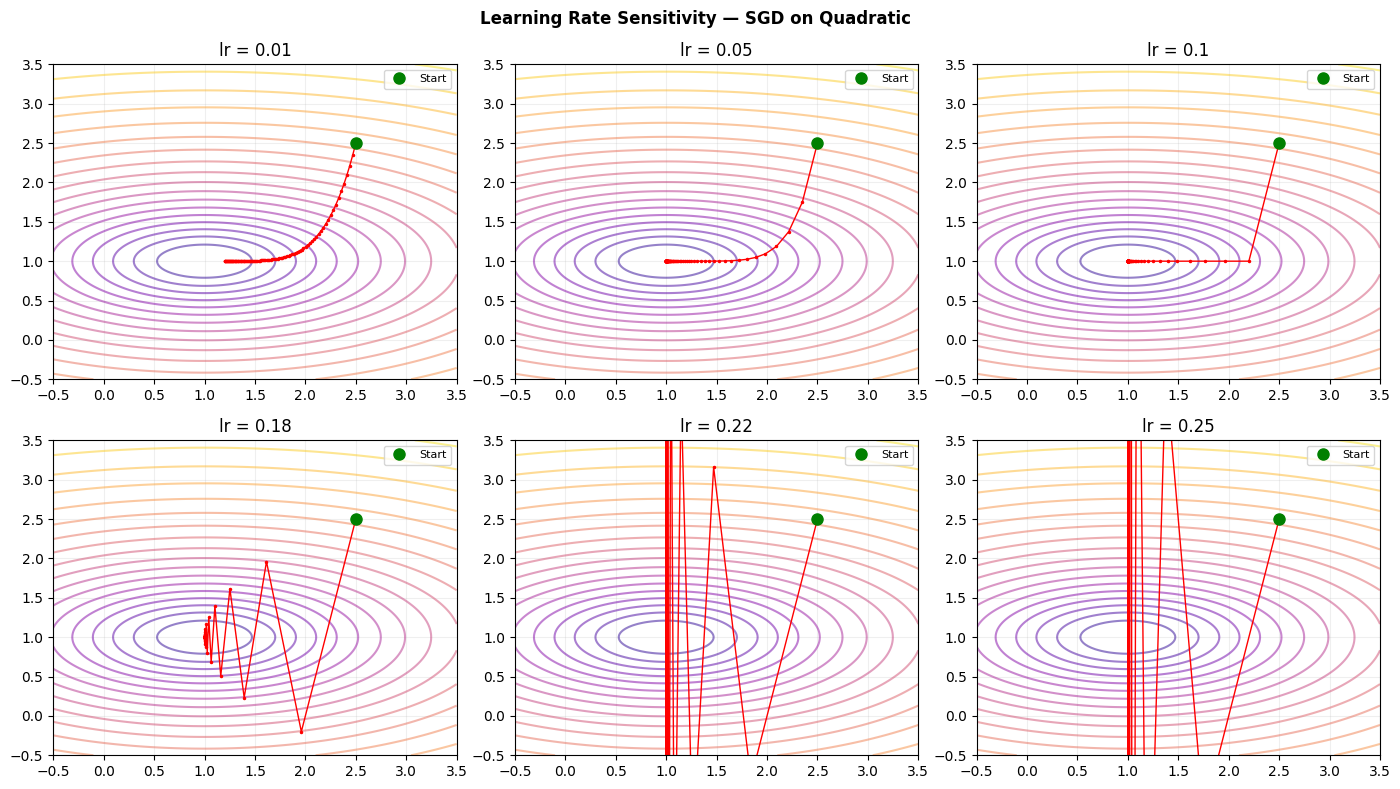

In [5]:
# How does learning rate affect convergence on a simple quadratic?
loss_fn, grad_fn, w0_quad, xlim, ylim = surfaces['Quadratic (ideal)']

lr_values = [0.01, 0.05, 0.1, 0.18, 0.22, 0.25]
n_steps = 100

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
xs = np.linspace(*xlim, 200)
ys = np.linspace(*ylim, 200)
X, Y = np.meshgrid(xs, ys)
Z = np.vectorize(lambda x, y: loss_fn([x, y]))(X, Y)

for ax, lr in zip(axes.flat, lr_values):
    ax.contour(X, Y, np.log1p(Z), levels=20, cmap='plasma', alpha=0.5)
    path = run_optimizer(SGD(lr=lr), grad_fn, np.array(w0_quad), n_steps)
    ax.plot(path[:, 0], path[:, 1], 'r.-', ms=3, lw=1)
    ax.plot(path[0, 0], path[0, 1], 'go', ms=8, label='Start')
    ax.set_title(f'lr = {lr}'); ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.suptitle('Learning Rate Sensitivity — SGD on Quadratic', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('ch228_lr_sensitivity.png', dpi=100); plt.show()


## 5. Results & Reflection

**What was built:** A trajectory visualizer that shows gradient descent paths on three canonical loss surfaces — a well-conditioned quadratic, the notoriously difficult Rosenbrock valley, and a saddle point.

**What math made it possible:**
- Gradients *(ch209)* give the direction of steepest ascent at each point
- The chain rule *(ch215)* lets us compute those gradients analytically
- Momentum and Adam *(ch227)* accumulate gradient history to overcome oscillation
- Quadratic approximation *(ch219)* explains why learning rate > 2/L causes divergence

**Extension challenges:**
1. Add Nesterov momentum (look-ahead gradient evaluation) and compare its path on the Rosenbrock surface to standard momentum.
2. Implement a learning rate scheduler (e.g., cosine annealing) and observe its effect on final convergence.
3. Add a 3D surface plot that rotates in sync with the 2D trajectory animation.